In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib
import varray as va
import ldax_analysis as lan
from matplotlib.patches import Ellipse
from scipy.optimize import curve_fit
import tqdm
plt.style.use('../style.mplstyle')
rq_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004/'

#Enter what data sets you want to analyze followed by number of files to process
dates = [
     '2026-07-14-0846,50',
     '2026-07-14-1159,50',
     '2026-07-14-1507,50',
         ]
dataset_labels = [
     'Ba133 - C:-1.5kV',
     'Ba133 - C:-0.8kV',
     'Ba133 - C:-2.0kV',
]

RQ_names = [
    'p_phe',
    'p_aft',
    'p_bnds',
    'e_timestamps',
    'ss_s1_phe_ch',
    'ss_s1_phe',
    'ss_s1_aft',
    'ss_s1_mhf',
    'ss_s2_phe_ch',
    'ss_s2_phe',
    'ss_s2_aft',
    'ss_s2_x_raw',
    'ss_s2_y_raw',
    'ss_s2_r_raw',
    'ss_s2_drift_time',
    'ss_bad_phe',
    'ss_e_timestamps'
]

In [3]:
#Collect all data from selected files and store them in dict
d = {}
for pair in dates:
    date = pair.split(",")[0]
    numOfFiles = pair.split(",")[1]
    files = []
    label = dataset_labels[dates.index(pair)]
    print("Collecting data for " + label)
    for i in range(0, int(numOfFiles), 1):
        if i < 10:
                file = date + "_00000" + str(i)
        elif i < 100:
            file = date + "_0000" + str(i)
        else:
            file = date + "_000" + str(i)

        files.append(rq_path+file+'_RQ.vrz')

    d[label] = lan.concat_RQ_files([f'{file}' for file in files], RQ_names)
    print("Finished collecting data for " + label)

Finished collecting data for Ba133 - C:-1.5kV
Finished collecting data for Ba133 - C:-0.8kV
Finished collecting data for Ba133 - C:-2.0kV


In [4]:
#Process RQs for easy calls
for label in dataset_labels:
    dataset = d[label]
    dataset['ss_s2_top_phe'] = np.sum(dataset['ss_s2_phe_ch'][:16], axis=0) #phe
    dataset['ss_s2_bot_phe'] = np.sum(dataset['ss_s2_phe_ch'][-16:], axis=0) #phe
    dataset['ss_s2_tba'] = (dataset['ss_s2_top_phe'] - dataset['ss_s2_bot_phe'])/dataset['ss_s2_phe'] #unitless
    dataset['ss_good_phe'] = dataset['ss_s2_phe'] + dataset['ss_s1_phe'] #phe
    dataset['ss_s2_width595'] = dataset['ss_s2_aft'][6] - dataset['ss_s2_aft'][0] #samples
    dataset['ss_trig_timestamp'] = (dataset['ss_e_timestamps'] - dataset['ss_e_timestamps'][0])*10**-8 #seconds
    dataset['trig_timestamp'] = (dataset['e_timestamps'] - dataset['e_timestamps'][0])*10**-8 #seconds
    dataset['p_width595'] = dataset['p_aft'][:,6] - dataset['p_aft'][:,0] #samples

In [5]:
def plot2d(
    x,
    y,
    x_range=None,
    y_range=None,
    x_bins=50,
    y_bins=50,
    flag_log=False,
    flag_mask=True,
    y_log_scale=False,
    cmap=None,
):
    if cmap is None:
        cmap = matplotlib.cm.viridis

    if x_range is None:
        x_range = [x.min(), x.max()]
    if y_range is None:
        y_range = [y.min(), y.max()]

    if x_range[1] < x_range[0]:
        x_range = x_range[::-1]
    if y_range[1] < y_range[0]:
        y_range = y_range[::-1]

    # x bin edges (always linear)
    x_xe = np.linspace(x_range[0], x_range[1], x_bins + 1)

    # y bin edges
    if y_log_scale:
        if y_range[0] <= 0:
            raise ValueError("y_range must be positive for logarithmic y scale.")
        x_ye = np.logspace(
            np.log10(y_range[0]),
            np.log10(y_range[1]),
            y_bins + 1,
        )
    else:
        x_ye = np.linspace(y_range[0], y_range[1], y_bins + 1)

    # Histogram
    n = np.histogramdd(np.column_stack((x, y)), bins=[x_xe, x_ye])[0]

    if flag_mask:
        n_max = n[n > 0].max()
        n_min = n[n > 0].min()
        n = np.ma.masked_where(n <= 0, n)
    else:
        if flag_log:
            n[n <= 0] = 0.1
        n_max = n.max()
        n_min = n.min()

    # Color normalization
    if flag_log:
        n_Norm = matplotlib.colors.LogNorm(vmin=n_min, vmax=n_max)
    else:
        n_Norm = matplotlib.colors.Normalize(vmin=n_min, vmax=n_max)

    h = plt.pcolormesh(
        x_xe,
        x_ye,
        n.T,
        norm=n_Norm,
        cmap=cmap,
        shading="auto",
    )

    h.set_edgecolor("face")
    h.set_linewidth(0.001)

    if y_log_scale:
        plt.yscale("log")

    if flag_log and not flag_mask:
        cMax = h.get_clim()[1]
        h.set_clim((0.8, cMax))

    return n

In [6]:
#Define Cuts
for label in dataset_labels:
    dataset = d[label]
    dataset['drift_time_cut'] = ((dataset['ss_s2_drift_time'] < 750) & (dataset['ss_s2_drift_time'] > 250))
    dataset['pulse_width_cut'] = (dataset['ss_s2_width595'] > 102) & (dataset['ss_s2_width595'] < 160)
    dataset['bad_area_cut'] = ((dataset['ss_bad_phe'] < 0.8*np.log10(dataset['ss_good_phe'])**5) & (dataset['ss_bad_phe'] > 1e-2))
    dataset['tba_cut'] = ((dataset['ss_s2_tba'] < 0.2) & (dataset['ss_s2_tba'] > 0))
    dataset['mhf_cut'] = (dataset['ss_s1_mhf'] < 1.3*dataset['ss_s1_phe']**-0.7+0.08)

/tmp/ipykernel_1305481/325336311.py:8: RuntimeWarning: invalid value encountered in power
  dataset['mhf_cut'] = (dataset['ss_s1_mhf'] < 1.3*dataset['ss_s1_phe']**-0.7+0.08)
/tmp/ipykernel_1305481/325336311.py:6: RuntimeWarning: invalid value encountered in log10
  dataset['bad_area_cut'] = ((dataset['ss_bad_phe'] < 0.8*np.log10(dataset['ss_good_phe'])**5) & (dataset['ss_bad_phe'] > 1e-2))


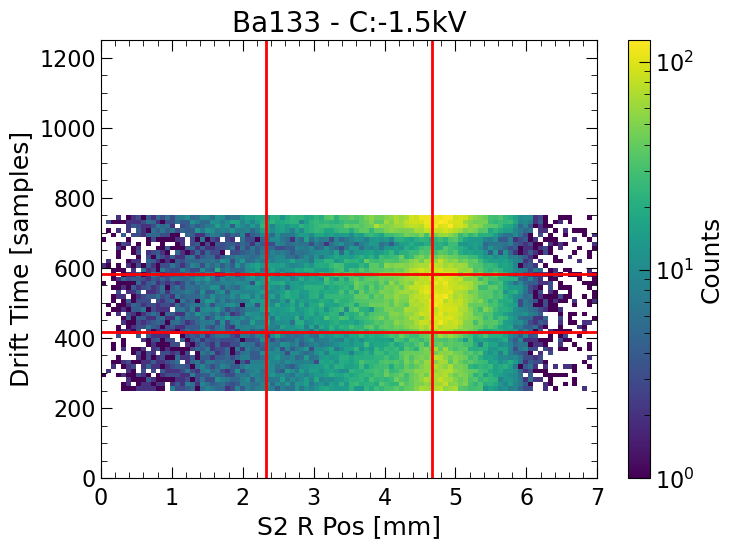

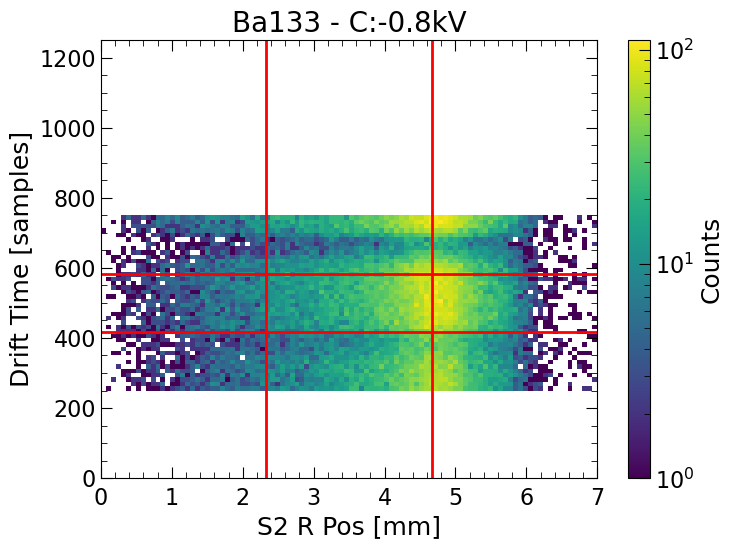

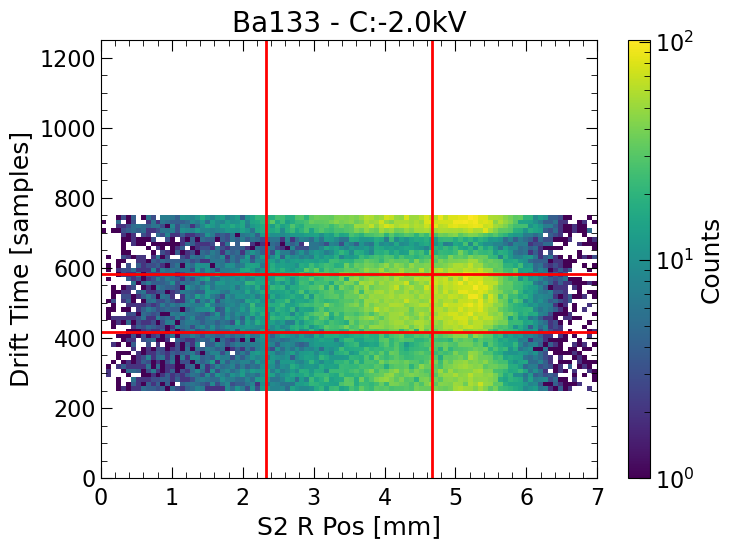

In [7]:
for label in dataset_labels:
    dataset = d[label]
    #Apply Cuts
    master_cut = dataset['mhf_cut'] & dataset['drift_time_cut'] & dataset['tba_cut'] & dataset['bad_area_cut'] & dataset['pulse_width_cut']
    plot2d(dataset['ss_s2_r_raw'][master_cut], dataset['ss_s2_drift_time'][master_cut], (0, 7), (0, 1250), x_bins=100, y_bins=100, flag_log=True)
    plt.colorbar(label="Counts")
    plt.title(label)
    plt.xlabel("S2 R Pos [mm]")
    plt.ylabel("Drift Time [samples]")
    plt.axhline(y=500/3+250, color='red')
    plt.axhline(y=1000/3+250, color='red')
    plt.axvline(x=7/3, color='red')
    plt.axvline(x=14/3, color='red')
    
    dataset['systematic_error_cuts'] = {}

    dataset['systematic_error_cuts']['upper_left_cut'] = (dataset['ss_s2_drift_time'] > 1750/3) & (dataset['ss_s2_r_raw'] < 7/3)

    dataset['systematic_error_cuts']['upper_middle_cut'] = (dataset['ss_s2_drift_time'] > 1750/3) & (dataset['ss_s2_r_raw'] > 7/3) & (dataset['ss_s2_r_raw'] < 14/3)
    dataset['systematic_error_cuts']['upper_right_cut'] = (dataset['ss_s2_drift_time'] > 1750/3) & (dataset['ss_s2_r_raw'] > 14/3)

    dataset['systematic_error_cuts']['middle_left_cut'] = (dataset['ss_s2_drift_time'] > 1250/3) & (dataset['ss_s2_drift_time'] < 1750/3) & (dataset['ss_s2_r_raw'] < 7/3)
    dataset['systematic_error_cuts']['middle_middle_cut'] = (dataset['ss_s2_drift_time'] > 1250/3) & (dataset['ss_s2_drift_time'] < 1750/3) & (dataset['ss_s2_r_raw'] > 7/3) & (dataset['ss_s2_r_raw'] < 14/3)
    dataset['systematic_error_cuts']['middle_right_cut'] = (dataset['ss_s2_drift_time'] > 1250/3) & (dataset['ss_s2_drift_time'] < 1750/3) & (dataset['ss_s2_r_raw'] > 14/3)

    dataset['systematic_error_cuts']['lower_left_cut'] = (dataset['ss_s2_drift_time'] < 1250/3) & (dataset['ss_s2_r_raw'] < 7/3)
    dataset['systematic_error_cuts']['lower_middle_cut'] = (dataset['ss_s2_drift_time'] < 1250/3) & (dataset['ss_s2_r_raw'] > 7/3) & (dataset['ss_s2_r_raw'] < 14/3)
    dataset['systematic_error_cuts']['lower_right_cut'] = (dataset['ss_s2_drift_time'] < 1250/3) & (dataset['ss_s2_r_raw'] > 14/3)   

    dataset['systematic_error_cuts']['control'] = True
    plt.show()

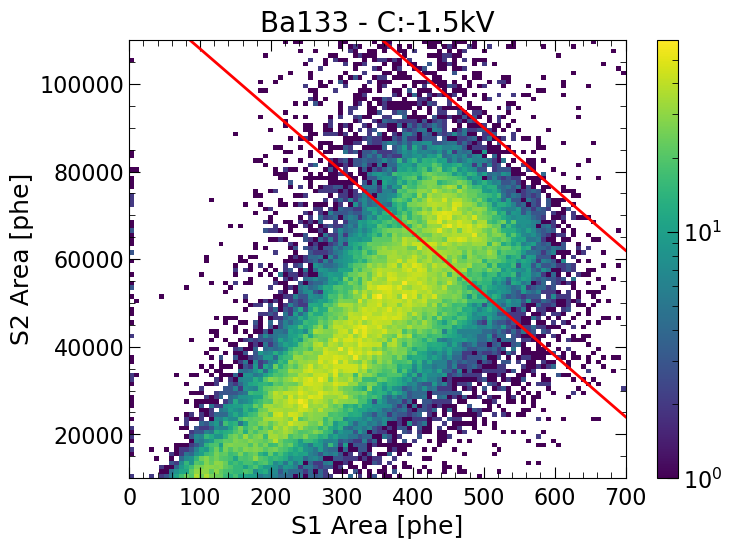

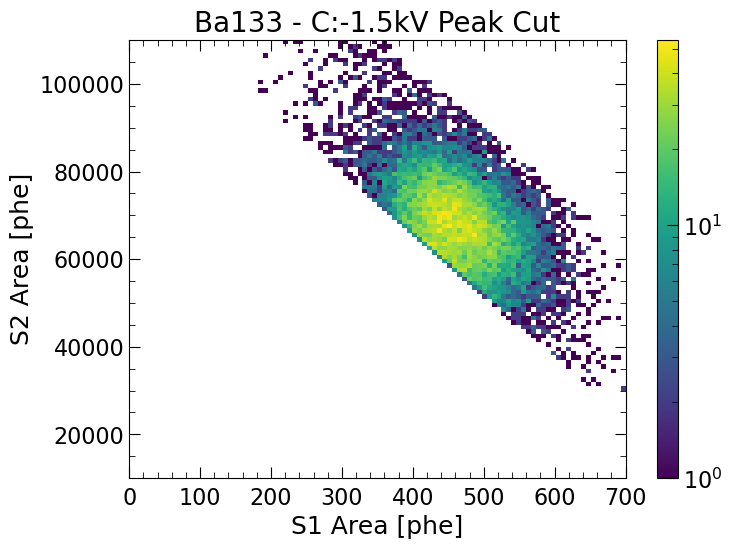

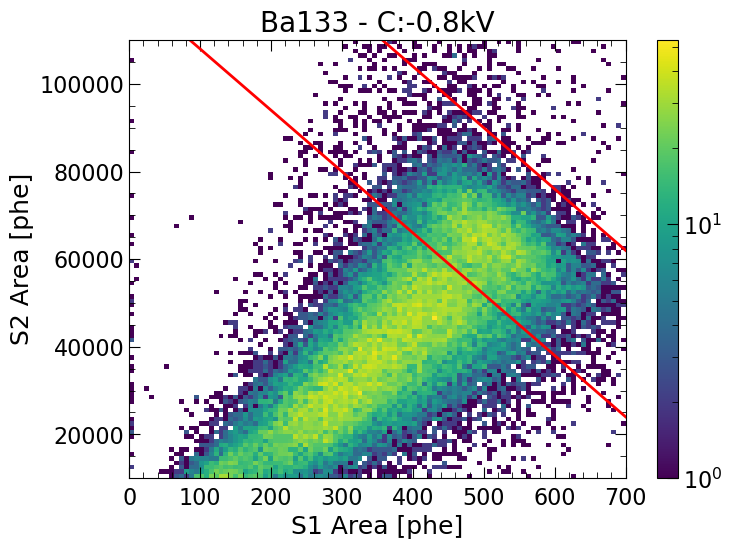

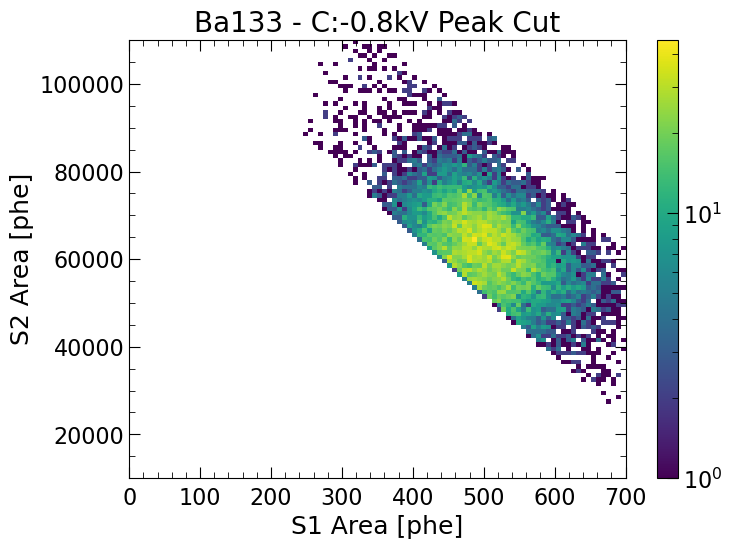

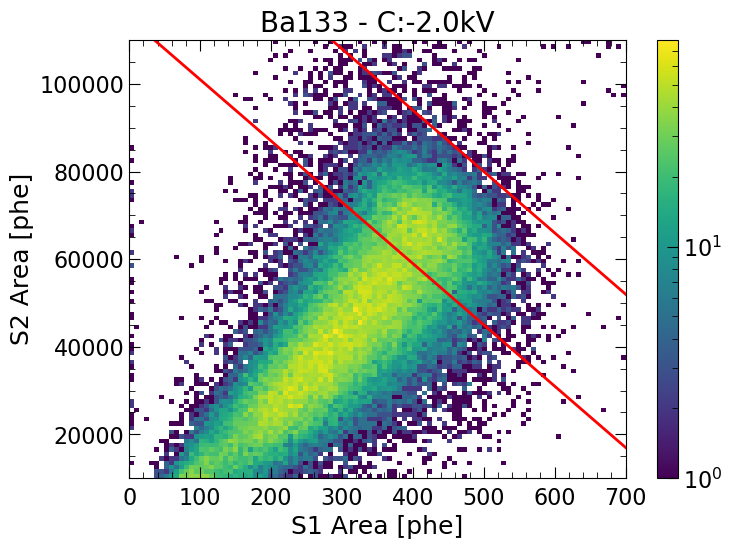

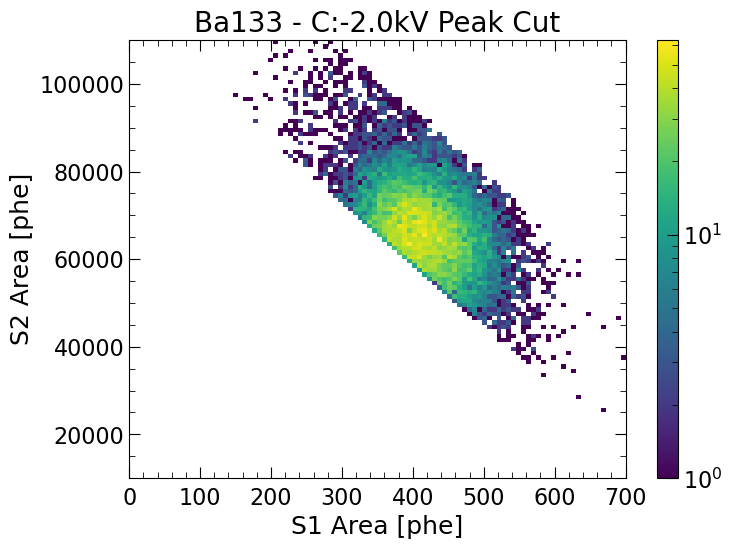

In [8]:
'''ellipse_vars = [
    [4.7e2, 7.1e4, 2e4, 1e2, -89.7],
    [5.2e2, 6.6e4, 2e4, 1e2, -89.7],
    [4.3e2, 7.e4, 2e4, 1e2, -89.7]
]'''

line_vars = np.array([
    [-140, 1.22e5, -140, 1.6e5],
    [-140, 1.22e5, -140, 1.6e5],
    [-140, 1.15e5, -140, 1.5e5]
])

for label in dataset_labels:
    dataset = d[label]
    label_index = dataset_labels.index(label)

    #Apply Cuts
    master_cut = dataset['mhf_cut'] & dataset['drift_time_cut'] & dataset['tba_cut'] & dataset['bad_area_cut'] & dataset['pulse_width_cut']
    s1_area_cut = dataset['ss_s1_phe'][master_cut]
    s2_area_cut = dataset['ss_s2_phe'][master_cut]

    s1_area = dataset['ss_s1_phe']
    s2_area = dataset['ss_s2_phe']

    plot2d(s1_area_cut, s2_area_cut, (0,7e2), (1e4, 1.1e5), x_bins=100, y_bins=100, flag_log=True)

    x = np.linspace(0, 700, 50)
    m1 = line_vars[label_index, 0]
    b1 = line_vars[label_index, 1]
    m2 = line_vars[label_index, 2]
    b2 = line_vars[label_index, 3]

    plt.plot(x, m1 * x + b1, color='red')
    plt.plot(x, m2 * x + b2, color='red')

    '''#Pass ellipse cut parameters
    dataset['x0'] = ellipse_vars[label_index][0]
    dataset['y0'] = ellipse_vars[label_index][1]
    dataset['a'] = ellipse_vars[label_index][2]
    dataset['b'] = ellipse_vars[label_index][3]
    dataset['thetaDeg'] = ellipse_vars[label_index][4]

    ellipse = Ellipse(
        xy=(dataset['x0'], dataset['y0']),
        width=2*dataset['a'],
        height=2*dataset['b'],
        angle=dataset['thetaDeg'],
        edgecolor='blue',
        facecolor='none',
        linewidth=2
    )

    ellipiticalCut = (((s1_area_cut-dataset['x0'])*np.cos(np.radians(dataset['thetaDeg']))+(s2_area_cut-dataset['y0'])*np.sin(np.radians(dataset['thetaDeg'])))**2 /dataset['a']**2 + 
                      ((s1_area_cut-dataset['x0'])*np.sin(np.radians(dataset['thetaDeg']))-(s2_area_cut-dataset['y0'])*np.cos(np.radians(dataset['thetaDeg'])))**2/dataset['b']**2) < 1
    dataset['ellipiticalCut'] = ellipiticalCut'''

    peak_cut = ((m1 * s1_area + b1) < s2_area) & \
        ((m2 * s1_area + b2) > s2_area)
    dataset['peak_cut'] = peak_cut

    #ax.add_patch(ellipse)
    plt.colorbar()
    #plt.ticklabel_format(axis='both', style='sci', scilimits=(3,1))
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("S2 Area [phe]")
    plt.title(label)
    plt.ylim(1e4, 1.1e5)
    plt.show()

    x = plot2d(s1_area[peak_cut & master_cut], s2_area[peak_cut & master_cut], (0,7e2), (1e4, 1.1e5), x_bins=100, y_bins=100, flag_log=True)

    plt.colorbar()
    #plt.ticklabel_format(axis='both', style='sci', scilimits=(3,1))
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("S2 Area [phe]")
    plt.title(label + " Peak Cut")
    plt.show()

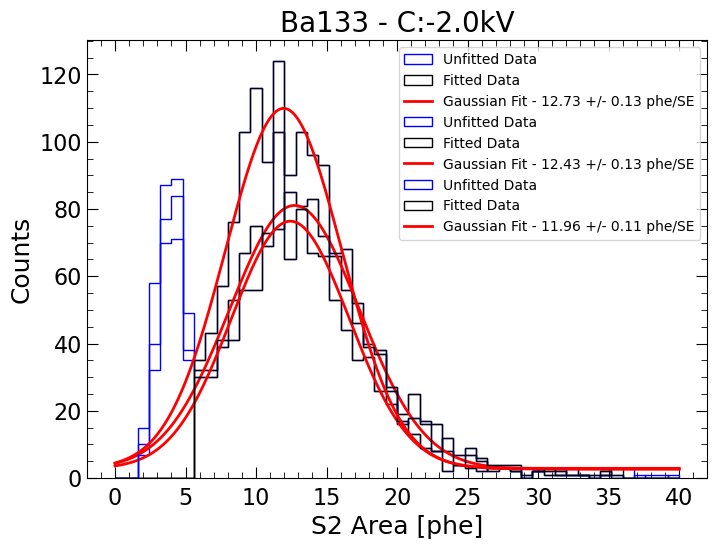

In [9]:
for label in dataset_labels:
    dataset = d[label]
    master_cut = dataset['mhf_cut'] & dataset['drift_time_cut'] & dataset['tba_cut'] & dataset['bad_area_cut'] & dataset['pulse_width_cut']
    s2_area_cut = dataset['ss_s2_phe'][master_cut]
    n, bins = np.histogram(s2_area_cut, range=(0,40), bins = 50)

    # Bin centers
    x = 0.5 * (bins[:-1] + bins[1:])[7:45]
    counts = n[7:45]
    # Gaussian model
    def gaussian(x, A, mu, sigma, C):
        return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + C

    # Initial guesses
    A0 = counts.max() - counts.min()
    mu0 = x[np.argmax(counts)]
    sigma0 = np.std(np.repeat(x, counts.astype(int)))  # or (x.max()-x.min())/6
    C0 = counts.min()

    # Fit
    popt, pcov = curve_fit(
        gaussian,
        x,
        counts,
        p0=[A0, mu0, sigma0, C0]
    )

    A, se_size, se_error, C = popt
    se_error = np.abs(se_error/np.sqrt(np.sum(counts)))

    xfine = np.linspace(bins[0], bins[-1], 500)

    plt.hist(
        0.5 * (bins[:-1] + bins[1:]),
        bins=bins,
        weights=n,
        histtype="step",
        color="blue",
        label="Unfitted Data"
    )

    plt.hist(
        x,
        bins=bins,
        weights=counts,
        histtype="step",
        color="k",
        label="Fitted Data"
    )

    plt.plot(
        xfine,
        gaussian(xfine, *popt),
        "r-",
        lw=2,
        label="Gaussian Fit - %.2f +/- %.2f phe/SE" % (se_size, se_error)
    )
    dataset['se_size'] = se_size
    dataset['se_error'] = se_error

    plt.xlabel("S2 Area [phe]")
    plt.ylabel("Counts")
    plt.title(label)
    plt.legend()

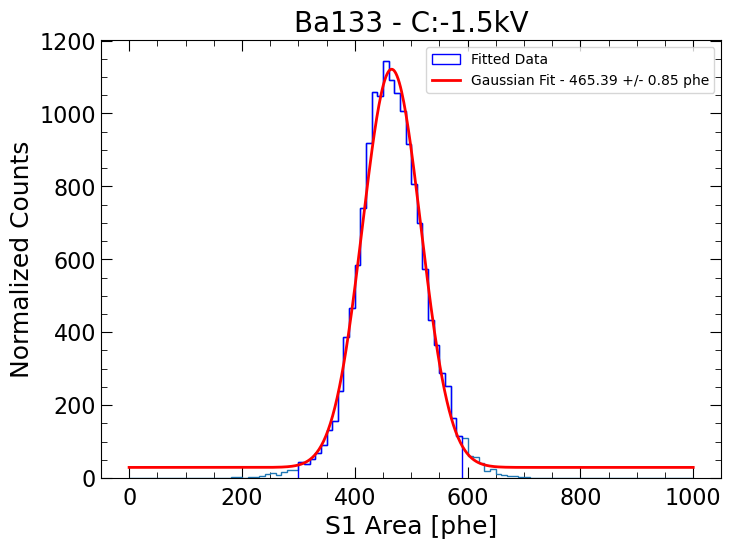

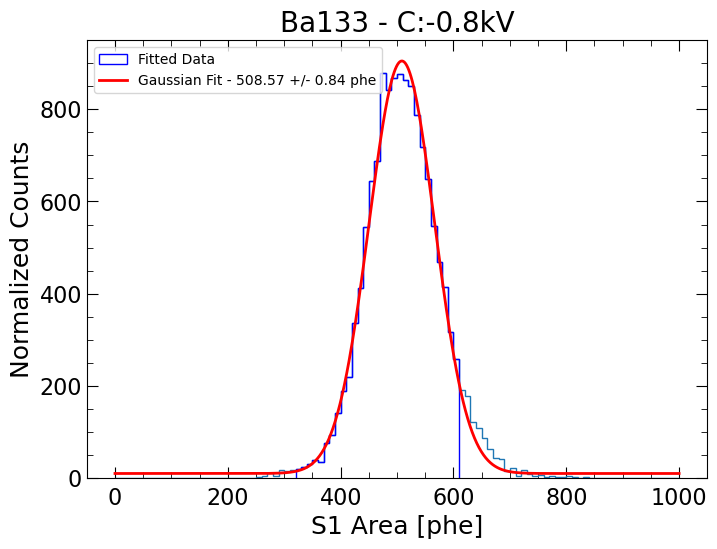

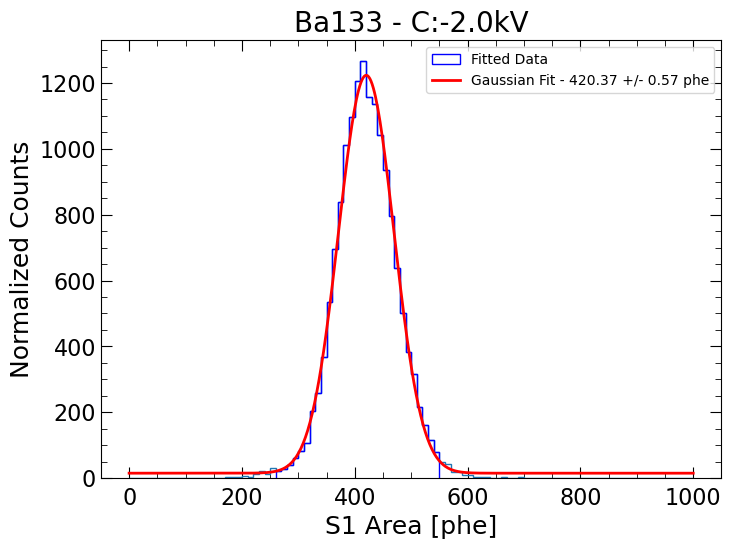

In [10]:
for label in dataset_labels:
    dataset = d[label]
    tempS1Area = []
    tempS1Error = []
    y_offset = 0
    
    master_cut = dataset['mhf_cut'] & dataset['drift_time_cut'] & \
        dataset['tba_cut'] & \
        dataset['bad_area_cut'] & \
        dataset['pulse_width_cut'] & \
        dataset['peak_cut']
    s1_area_cut = dataset['ss_s1_phe'][master_cut]
    counts, bins = np.histogram(s1_area_cut, range=(0,1e3), bins=100)
    temp_index = np.argmax(counts)
    # Bin centers
    x = 0.5 * (bins[:-1] + bins[1:])[temp_index-15:temp_index+15]
    

    # Initial guesses
    A0 = counts.max() - counts.min()
    mu0 = x[np.argmax(counts[temp_index-15:temp_index+15])]
    sigma0 = np.std(np.repeat(x, counts[temp_index-15:temp_index+15].astype(int)))  # or (x.max()-x.min())/6
    C0 = counts.min()

    # Fit
    popt, pcov = curve_fit(
        gaussian,
        x,
        counts[temp_index-15:temp_index+15],
        sigma=np.sqrt(np.where(counts[temp_index-15:temp_index+15] == 0, 1, counts[temp_index-15:temp_index+15])),
        p0=[A0, mu0, sigma0, C0]
    )

    _, fitted_s1_area, _, _ = popt
    _, fitted_s1_error, _, _ = np.sqrt(np.diag(pcov))

    xfine = np.linspace(bins[0], bins[-1], 500)

    plt.hist(
            0.5 * (bins[:-1] + bins[1:]),
            bins=bins,
            weights=counts,
            histtype="step",
            #label=cut
        )
    
    plt.hist(
        x,
        bins=bins[temp_index-15:temp_index+15],
        weights=counts[temp_index-15:temp_index+15],
        histtype="step",
        color="blue",
        label="Fitted Data"
    )

    plt.plot(
        xfine,
        gaussian(xfine, *popt),
        "r-",
        lw=2,
        label="Gaussian Fit - %.2f +/- %.2f phe" % (fitted_s1_area, fitted_s1_error)
    )

        
    dataset['fitted_s1_area'] = fitted_s1_area
    dataset['fitted_s1_error'] = fitted_s1_error
    plt.xlabel("S1 Area [phe]")
        #plt.ylim(0, np.max(counts)+50)
    plt.ylabel("Normalized Counts")
    plt.title(label)
    plt.legend()
    plt.show()

In [11]:
for label in dataset_labels:
    dataset = d[label]
    print(dataset['fitted_s1_area'])
    #print(dataset['stat_s1_error'])
    #print(dataset['sys_s1_error'])
    print(dataset['fitted_s1_error'])

465.3877833247178
0.84560078573189
508.5687362009842
0.8385925832856409
420.3689036798136
0.5741600919122081


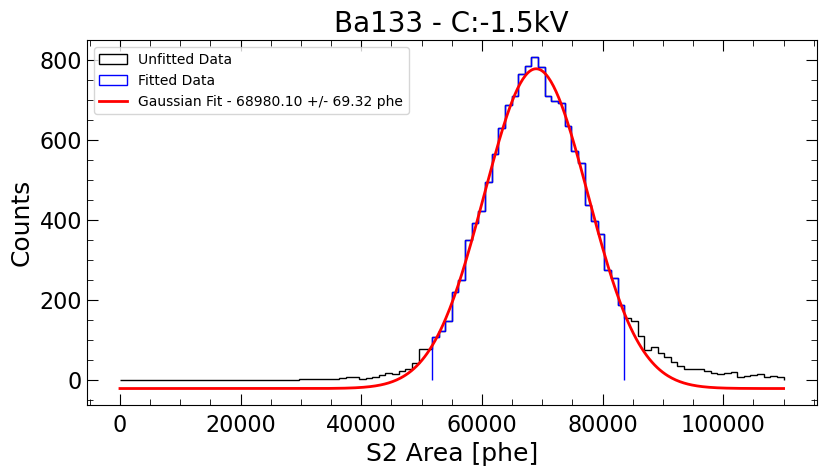

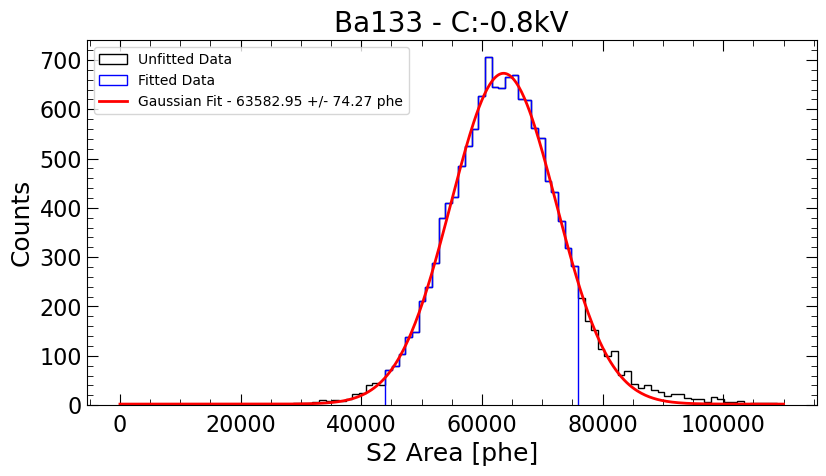

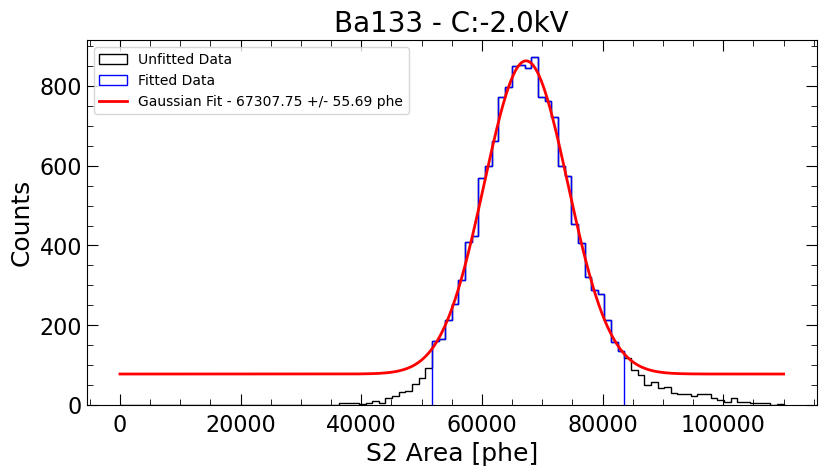

In [12]:
for label in dataset_labels:
    dataset = d[label]
    tempS2Area = []
    tempS2Error = []
    master_cut = dataset['mhf_cut'] & dataset['drift_time_cut'] & \
        dataset['tba_cut'] & \
        dataset['bad_area_cut'] & \
        dataset['pulse_width_cut'] & \
        dataset['peak_cut']
    
    s2_area_cut = dataset['ss_s2_phe'][master_cut]

    counts, bins = np.histogram(s2_area_cut, range=(0,1.1e5), bins=100)
    # Bin centers
    temp_index = np.argmax(counts)
    x = 0.5 * (bins[:-1] + bins[1:])[temp_index-15:temp_index+15]

    # Initial guesses
    A0 = counts.max() - counts.min()
    mu0 = x[np.argmax(counts[temp_index-15:temp_index+15])]
    sigma0 = np.std(np.repeat(x, counts[temp_index-15:temp_index+15].astype(int)))  # or (x.max()-x.min())/6
    C0 = counts.min()

    # Fit
    popt, pcov = curve_fit(
        gaussian,
        x,
        counts[temp_index-15:temp_index+15],
        p0=[A0, mu0, sigma0, C0],
        sigma=np.sqrt(counts[temp_index-15:temp_index+15])
    )

    _, fitted_s2_area, fitted_s2_error, _ = popt

    fitted_s2_error = np.abs(fitted_s2_error/np.sqrt(np.sum(counts)))

    xfine = np.linspace(bins[0], bins[-1], 500)
    plt.figure(figsize=(10,5))
    plt.hist(
        0.5 * (bins[:-1] + bins[1:]),
        bins=bins,
        weights=counts,
        histtype="step",
        color="k",
        label="Unfitted Data"
    )
        
    plt.hist(
        x,
        bins=bins[temp_index-15:temp_index+15],
        weights=counts[temp_index-15:temp_index+15],
        histtype="step",
        color="blue",
        label="Fitted Data"
    )

    plt.plot(
        xfine,
        gaussian(xfine, *popt),
        "r-",
        lw=2,
        label="Gaussian Fit - %.2f +/- %.2f phe" % (fitted_s2_area, fitted_s2_error)
    )
    dataset['fitted_s2_area'] = fitted_s2_area
    dataset['fitted_s2_error'] = fitted_s2_error
    plt.xlabel("S2 Area [phe]")
    plt.ylabel("Counts")
    plt.title(label)
    plt.legend()
    plt.show()

In [13]:
for label in dataset_labels:
    dataset = d[label]
    print(dataset['fitted_s2_area'])
    #print(dataset['stat_s1_error'])
    #print(dataset['sys_s1_error'])
    print(dataset['fitted_s2_error'])

68980.09501159089
69.31880624010563
63582.95130658227
74.27081992865787
67307.75214512768
55.685488290780896


[465.3877833247178, 508.5687362009842, 420.3689036798136]
[0.84560078573189, 0.8385925832856409, 0.5741600919122081]
[5420.502606176087, 5113.412570623614, 5628.606420430477]
[57.667517126797264, 54.184435656415815, 51.922164776764674]


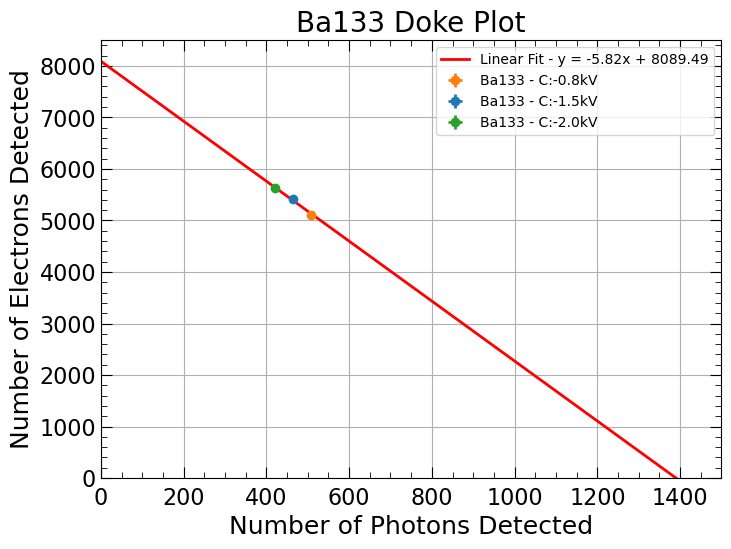

-5.81774455156438
8089.492412561826


In [14]:
def linear_model(x, m, c):
    return m * x + c

photon_data = []
photon_error = []
electron_data = []
electron_error = []


for label in dataset_labels:
    dataset = d[label]
    se_size = dataset['se_size']
    se_error = dataset['se_error']
    fitted_s1_area = dataset['fitted_s1_area']
    fitted_s2_area = dataset['fitted_s2_area']
    fitted_s1_error = dataset['fitted_s1_error']
    fitted_s2_error = dataset['fitted_s2_error']


    #Error Propagation
    relative_se_error = se_error/se_size
    relative_s2_error = fitted_s2_error/fitted_s2_area

    num_of_electrons = fitted_s2_area/se_size
    num_of_electrons_error = num_of_electrons * np.sqrt(relative_s2_error**2 + relative_se_error**2)

    electron_data.append(num_of_electrons)
    electron_error.append(num_of_electrons_error)

    num_of_photons = fitted_s1_area
    num_of_photons_error = fitted_s1_error

    photon_data.append(num_of_photons)
    photon_error.append(num_of_photons_error)

    plt.errorbar(num_of_photons, num_of_electrons, xerr=num_of_photons_error, yerr=num_of_electrons_error, fmt='o', label=label, markersize=6)

print(photon_data)
print(photon_error)
print(electron_data)
print(electron_error)

popt, pcov = curve_fit(linear_model, photon_data, electron_data, sigma=electron_error, absolute_sigma=True)
slope, intercept = popt
slope_err, intercept_err = np.sqrt(np.diag(pcov))

plt.plot(np.linspace(0, 1400), linear_model(np.linspace(0, 1400), *popt), label="Linear Fit - y = %.2fx + %.2f" % (slope, intercept), color='red')
plt.xlabel("Number of Photons Detected")
plt.ylabel("Number of Electrons Detected")
plt.title("Ba133 Doke Plot")
handles, labels = plt.gca().get_legend_handles_labels()
order = [0, 2, 1, 3]
plt.legend([handles[i] for i in order], [labels[i] for i in order])
plt.grid(True)
plt.xlim(0, 1500)
plt.ylim(0, 8500)
plt.show()

print(slope)
print(intercept)

420.3689036798136
67307.75214512768
0.5741600919122081
55.685488290780896


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 3103.91it/s]


Text(0, 0.5, 'S2 Area [extraced e$^-$]')

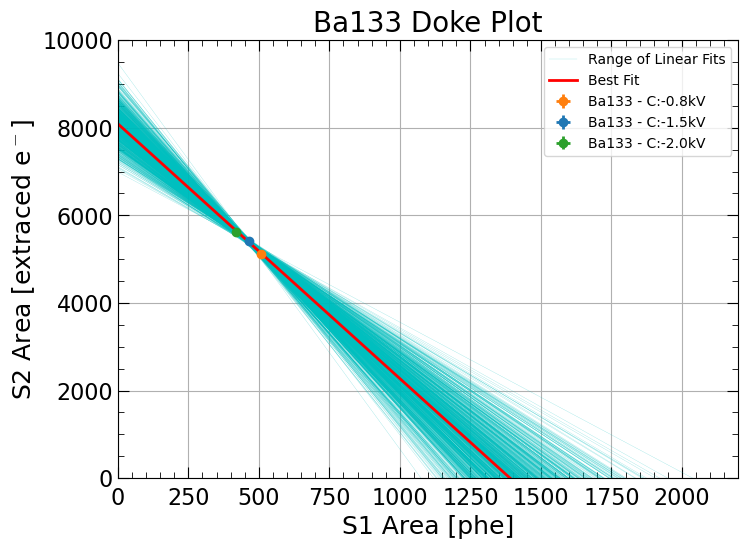

In [15]:
num_of_trials = 1000
photon_intercept = []
electron_intercept = []

true_photon_data = []
true_photon_error = []
true_electron_data = []
true_electron_error = []
for label in dataset_labels:
    dataset = d[label]
    se_size = dataset['se_size']
    se_error = dataset['se_error']
    fitted_s1_area = dataset['fitted_s1_area']
    fitted_s2_area = dataset['fitted_s2_area']
    fitted_s1_error = dataset['fitted_s1_error']
    fitted_s2_error = dataset['fitted_s2_error']


    #Error Propagation
    relative_se_error = se_error/se_size
    relative_s2_error = fitted_s2_error/fitted_s2_area

    num_of_electrons = fitted_s2_area/se_size
    num_of_electrons_error = num_of_electrons * np.sqrt(relative_s2_error**2 + relative_se_error**2)

    true_electron_data.append(num_of_electrons)
    true_electron_error.append(num_of_electrons_error)

    num_of_photons = fitted_s1_area
    num_of_photons_error = fitted_s1_error

    true_photon_data.append(num_of_photons)
    true_photon_error.append(num_of_photons_error)

    plt.errorbar(num_of_photons, num_of_electrons, xerr=num_of_photons_error, yerr=num_of_electrons_error, fmt='o', label=label, markersize=6)


print(dataset['fitted_s1_area'])
print(dataset['fitted_s2_area'])
print(dataset['fitted_s1_error'])
print(dataset['fitted_s2_error'])

for i in tqdm.tqdm(range(num_of_trials)):
    photon_data = []
    electron_data = []
    for label in dataset_labels:
        dataset = d[label]
        se_size = dataset['se_size']
        se_error = dataset['se_error']
        fitted_s1_area = dataset['fitted_s1_area']
        fitted_s2_area = dataset['fitted_s2_area']
        fitted_s1_error = dataset['fitted_s1_error']
        fitted_s2_error = dataset['fitted_s2_error']
    
        #Error Propagation
        relative_se_error = se_error/se_size
        relative_s2_error = fitted_s2_error/fitted_s2_area
    
        num_of_electrons = fitted_s2_area/se_size
        num_of_electrons_error = num_of_electrons * np.sqrt(relative_s2_error**2 + relative_se_error**2)
    
        num_of_photons = fitted_s1_area
        num_of_photons_error = fitted_s1_error
    
        sim_electron = np.random.normal(loc=num_of_electrons, scale=num_of_electrons_error)
        sim_photon = np.random.normal(loc=num_of_photons, scale=num_of_photons_error)

        electron_data.append(sim_electron)
        photon_data.append(sim_photon)

    popt, pcov = curve_fit(linear_model, photon_data, electron_data)
    slope, intercept = popt

    electron_intercept.append(intercept)
    photon_intercept.append(-1*intercept/slope)
    plt.plot(np.linspace(0, 10000, 20), linear_model(np.linspace(0, 10000, 20), *popt), label="Range of Linear Fits", color='c', linewidth=0.1)

popt, pcov = curve_fit(linear_model, true_photon_data, true_electron_data, sigma=true_electron_error, absolute_sigma=True)
slope, intercept = popt
slope_err, intercept_err = np.sqrt(np.diag(pcov))

plt.plot(np.linspace(0, 1400), linear_model(np.linspace(0, 1400), *popt), label="Best Fit", color='red')

handles, labels = plt.gca().get_legend_handles_labels()
order = [0, 1000, 1002, 1001, 1003]
plt.title("Ba133 Doke Plot")
plt.grid(True)
plt.legend([handles[i] for i in order], [labels[i] for i in order])
plt.xlim(0, 2200)
plt.ylim(0,10000)    
plt.xlabel(r"S1 Area [phe]")
plt.ylabel(r"S2 Area [extraced e$^-$]")



In [ ]:
counts, bins = np.histogram(photon_intercept, range=(1e2,1e4), bins=200)
# Bin centers
temp_index = np.argmax(counts)
x = 0.5 * (bins[:-1] + bins[1:])[temp_index-15:temp_index+15]

# Initial guesses
A0 = counts.max() - counts.min()
mu0 = x[np.argmax(counts[temp_index-15:temp_index+15])]
sigma0 = np.std(np.repeat(x, counts[temp_index-15:temp_index+15].astype(int)))  # or (x.max()-x.min())/6
C0 = counts.min()

# Fit
popt, pcov = curve_fit(
    gaussian,
    x,
    counts[temp_index-15:temp_index+15],
    p0=[A0, mu0, sigma0, C0],
)

_, fitted_photon_intercept, fitted_photon_intercept_error, _ = popt

fitted_photon_intercept_error = np.abs(fitted_photon_intercept_error/np.sqrt(np.sum(counts)))

xfine = np.linspace(bins[0], bins[-1], 500)
plt.figure(figsize=(10,5))
plt.hist(
    0.5 * (bins[:-1] + bins[1:]),
    bins=bins,
    weights=counts,
    histtype="step",
    color="k",
    label="Unfitted Data"
)

plt.hist(
    x,
    bins=bins[temp_index-15:temp_index+15],
    weights=counts[temp_index-15:temp_index+15],
    histtype="step",
    color="blue",
    label="Fitted Data"
)

plt.plot(
    xfine,
    gaussian(xfine, *popt),
    "r-",
    lw=2,
    label="Gaussian Fit - %.2f +/- %.2f phe" % (fitted_photon_intercept, fitted_photon_intercept_error)
)
plt.legend()
plt.yscale('log')

plt.xlabel("Number of Photons")
plt.ylabel("Counts")
plt.title("Photon Intercept")

ValueError: attempt to get argmax of an empty sequence

Text(0.5, 1.0, 'Electron Intercept')

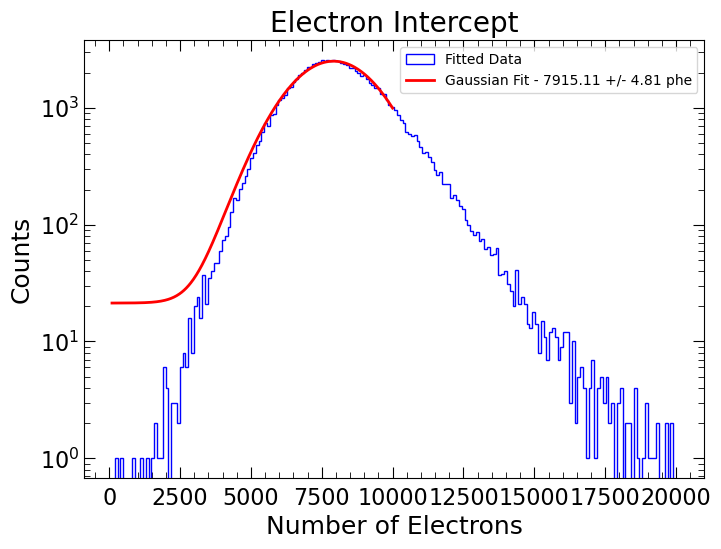

In [ ]:
counts, bins = np.histogram(electron_intercept, range=(1e2,2e4), bins=200)
# Bin centers
temp_index = np.argmax(counts)
x = 0.5 * (bins[:-1] + bins[1:])

# Initial guesses
A0 = counts.max() - counts.min()
mu0 = x[np.argmax(counts)]
sigma0 = np.std(np.repeat(x, counts.astype(int)))  # or (x.max()-x.min())/6
C0 = counts.min()

# Fit
popt, pcov = curve_fit(
    gaussian,
    x,
    counts,
    p0=[A0, mu0, sigma0, C0],
)

_, fitted_electron_intercept, fitted_electron_intercept_error, _ = popt

fitted_electron_intercept_error = np.abs(fitted_electron_intercept_error/np.sqrt(np.sum(counts)))

'''xfine = np.linspace(bins[0], bins[-1], 500)
plt.figure(figsize=(10,5))
plt.hist(
    0.5 * (bins[:-1] + bins[1:]),
    bins=bins,
    weights=counts,
    histtype="step",
    color="k",
    label="Unfitted Data"
)'''

plt.hist(
    x,
    bins=bins,
    weights=counts,
    histtype="step",
    color="blue",
    label="Fitted Data"
)

plt.plot(
    xfine,
    gaussian(xfine, *popt),
    "r-",
    lw=2,
    label="Gaussian Fit - %.2f +/- %.2f phe" % (fitted_electron_intercept, fitted_electron_intercept_error)
)
plt.legend()

plt.xlabel("Number of Electrons")
plt.ylabel("Counts")
plt.yscale("log")
plt.title("Electron Intercept")